In [11]:
import torch
from transformers import GPT2Tokenizer, GPT2LMHeadModel
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [12]:
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2')
text = "Chaos is inevitable in the modern"
encoded_input = tokenizer.encode(text, return_tensors='pt')
output = model.generate(encoded_input, max_length=50)
generated_text = tokenizer.decode(output[0], skip_special_tokens=True)


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In [14]:
print(generated_text)

Chaos is inevitable in the modern world.

The world is not a place where you can be a hero. It is a place where you can be a villain.

The world is a place where you can be a villain.



In [15]:
# Extract all weights into a single array
weights = []
for param in model.parameters():
    weights.extend(param.detach().cpu().numpy().flatten())

weights = np.array(weights)

In [20]:
print(len(weights))

124439808


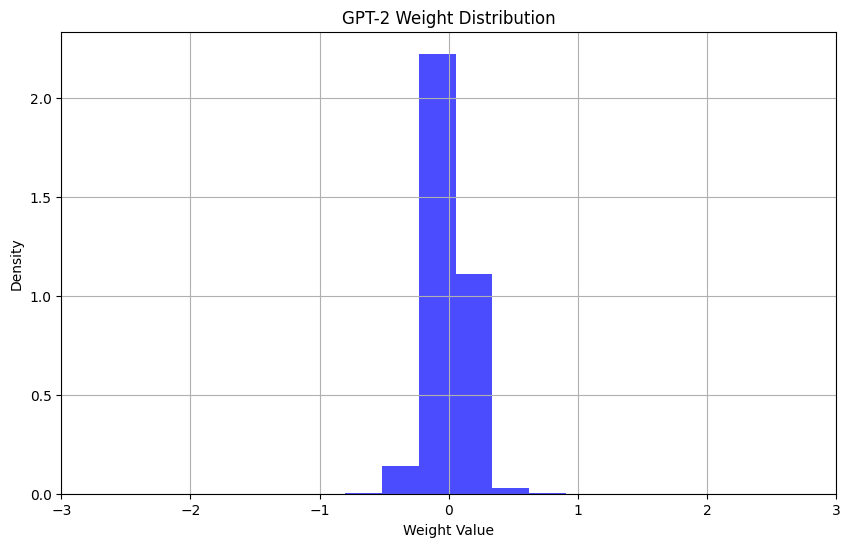

In [19]:
# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(weights, bins=100, density=True, alpha=0.7, color='blue')
plt.title('GPT-2 Weight Distribution')
plt.xlabel('Weight Value')
plt.ylabel('Density')
plt.xlim(-3, 3)
plt.grid(True)

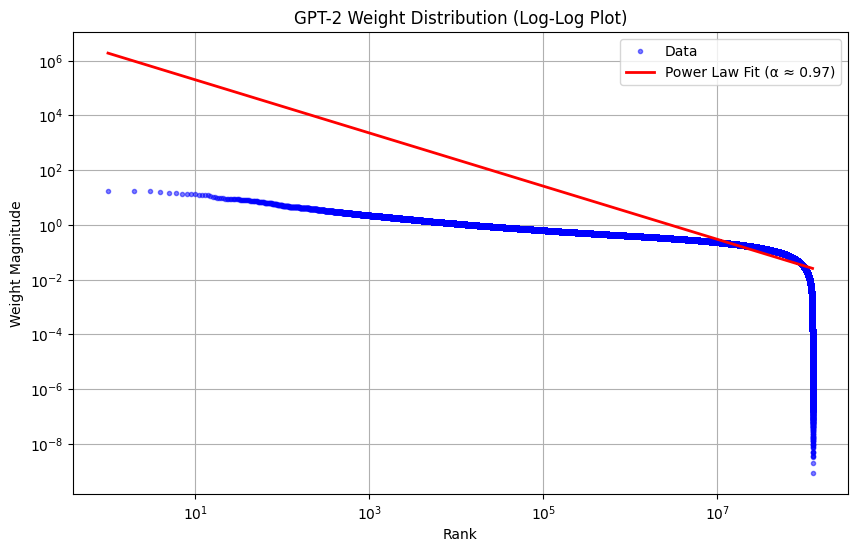

Power law exponent (alpha): 0.9707


In [23]:
weights_sorted = np.sort(np.abs(weights))[::-1]
ranks = np.arange(1, len(weights_sorted) + 1)

# Only fit the middle range to avoid extremes
start_idx = len(weights_sorted) // 100  # Skip first 1%
end_idx = len(weights_sorted) * 99 // 100  # Skip last 1%
mask = np.logical_and(ranks >= ranks[start_idx], ranks <= ranks[end_idx])

# Fit power law on log-transformed data
fit = np.polyfit(np.log(ranks[mask]), np.log(weights_sorted[mask]), 1)
alpha = -fit[0]

# Plot
plt.figure(figsize=(10, 6))
plt.loglog(ranks, weights_sorted, 'b.', alpha=0.5, label='Data')
x = np.logspace(np.log10(ranks[0]), np.log10(ranks[-1]), 100)
y = np.exp(fit[1]) * x**fit[0]
plt.loglog(x, y, 'r-', linewidth=2, label=f'Power Law Fit (α ≈ {alpha:.2f})')
plt.title('GPT-2 Weight Distribution (Log-Log Plot)')
plt.xlabel('Rank')
plt.ylabel('Weight Magnitude')
plt.legend()
plt.grid(True)
plt.show()

print(f"Power law exponent (alpha): {alpha:.4f}")

In [ ]:
import torch
import torch.nn as nn
from transformers import GPT2LMHeadModel
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, l1_lambda=0.1):
        super().__init__()
        self.encoder = nn.Linear(input_dim, hidden_dim)
        self.decoder = nn.Linear(hidden_dim, input_dim)
        self.l1_lambda = l1_lambda
        
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded, encoded
        
    def loss_function(self, x, x_hat, encoded):
        reconstruction_loss = nn.MSELoss()(x_hat, x)
        l1_loss = self.l1_lambda * encoded.abs().mean()
        return reconstruction_loss + l1_loss

def collect_activations(model, layer_idx=6):  # layer_idx 6 is middle layer
    activations = []
    
    def hook(module, input, output):
        activations.append(output[0].detach())  # [0] gets hidden states
        
    hook_handle = model.transformer.h[layer_idx].register_forward_hook(hook)
    
    # Generate some random inputs
    input_ids = torch.randint(0, model.config.vocab_size, (100, 20))
    model(input_ids)
    
    hook_handle.remove()
    return torch.cat(activations, dim=0)

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GPT2LMHeadModel.from_pretrained('gpt2').to(device)
activations = collect_activations(model)
hidden_dim = activations.shape[-1]

# Train autoencoder
autoencoder = SparseAutoencoder(hidden_dim, hidden_dim*2).to(device)  # 2x overcomplete
dataset = TensorDataset(activations)
loader = DataLoader(dataset, batch_size=32, shuffle=True)
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)

num_epochs = 100
for epoch in range(num_epochs):
    total_loss = 0
    for batch in loader:
        x = batch[0].to(device)
        optimizer.zero_grad()
        x_hat, encoded = autoencoder(x)
        loss = autoencoder.loss_function(x, x_hat, encoded)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

# Get learned features
feature_directions = autoencoder.encoder.weight.data